# Making meltwater mask

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import matplotlib.path as mpath
import xarray as xr
import cf_xarray
import cmocean as cm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

In [2]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [3]:
# Land and contour data
shelf_contour_1 = xr.open_dataset('/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc')['contour_masked_above']
depth_1 = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_static.nc')['deptho']
land_mask_1 = (0 * depth_1).fillna(1)
land_1 = xr.where(np.isnan(depth_1.rename('land_1')), 1, np.nan)


In [5]:
var = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_month_z.nc')['so']
var = var.isel(time=0,z_l=0)

/jobfs/161682780.gadi-pbs/ipykernel_743023/2768214134.py:1: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  var = xr.open_dataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output050/20050501.ocean_month_z.nc')['so']
/jobfs/161682780.gadi-pbs/ipykernel_743023/2768214134.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time_bnds' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead i

In [6]:
var

<xarray.DataArray 'so' (yh: 845, xh: 3600)> Size: 12MB
[3042000 values with dtype=float32]
Coordinates:
  * yh       (yh) float64 7kB -81.11 -81.07 -81.02 ... -37.3 -37.22 -37.14
  * xh       (xh) float64 29kB -279.9 -279.8 -279.7 -279.6 ... 79.75 79.85 79.95
    z_l      float64 8B 0.5413
    time     object 8B 2005-05-16 12:00:00
Attributes:
    units:          psu
    long_name:      Sea Water Salinity
    cell_methods:   area:mean z_l:mean yh:mean xh:mean time: mean
    cell_measures:  volume: volcello area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_salinity

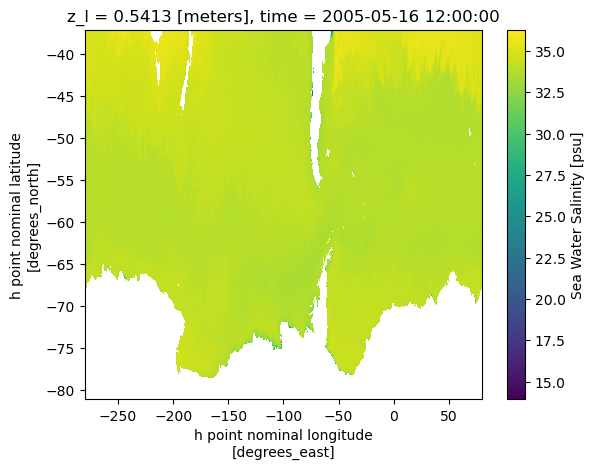

In [8]:
var.where(land_mask_1==0).plot()

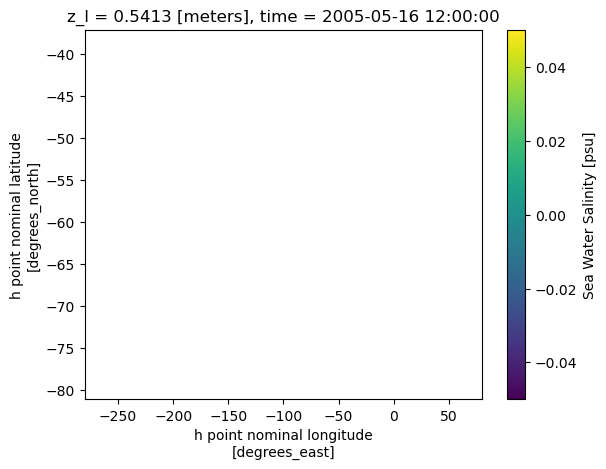

In [9]:
coast = var.where(land_mask_1==0.5)
coast.plot()

In [10]:
coast.max().compute()

<xarray.DataArray 'so' ()> Size: 8B
array(nan)
Coordinates:
    z_l      float64 8B 0.5413
    time     object 8B 2005-05-16 12:00:00

## 'Step' mask build

In [11]:
land_mask = xr.where(np.isnan(depth_1), 1, 0)
ocean_mask = 1 - land_mask

In [12]:
## Test adding diagonals 

# Cardinal directions
north = land_mask.shift(yh=-1)
south = land_mask.shift(yh=1)
east  = land_mask.shift(xh=-1)
west  = land_mask.shift(xh=1)

# Diagonals
ne = land_mask.shift(yh=-1, xh=1)
nw = land_mask.shift(yh=-1, xh=-1)
se = land_mask.shift(yh=1,  xh=1)
sw = land_mask.shift(yh=1,  xh=-1)

ocean_adjacent_to_land = (
    (ocean_mask == 1) &
    (
        (north == 1) | (south == 1) |
        (east  == 1) | (west  == 1) |
        (ne == 1) | (nw == 1) |
        (se == 1) | (sw == 1)
    )
).fillna(False)

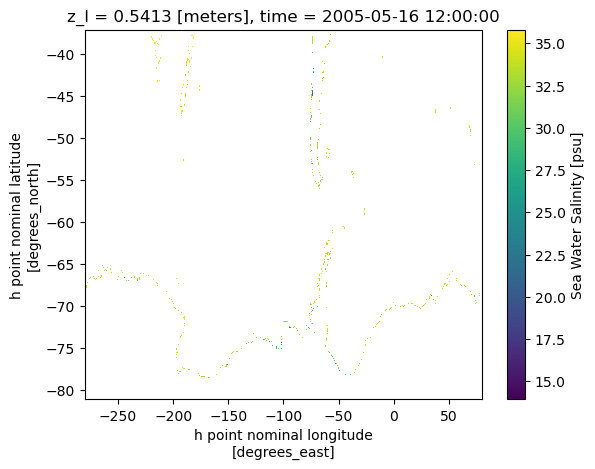

In [14]:
var.where(ocean_adjacent_to_land==1).plot()

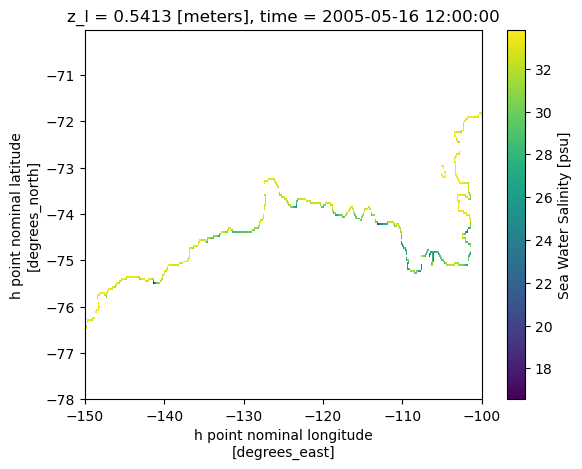

In [16]:
var.where(ocean_adjacent_to_land==1).sel(xh=slice(-150,-100),yh=slice(-78,-70)).plot()

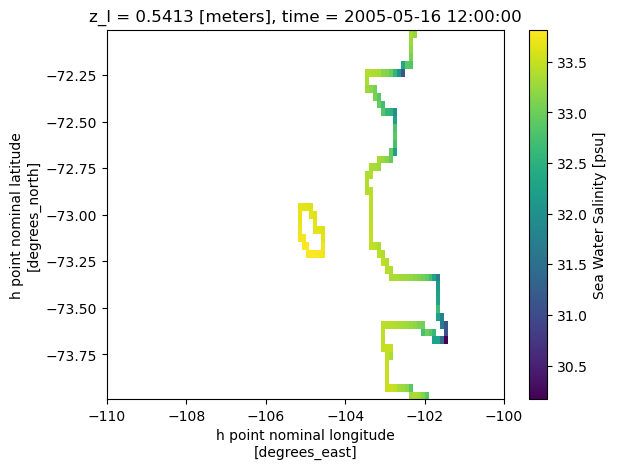

In [17]:
# Gap check
var.where(ocean_adjacent_to_land==1).sel(xh=slice(-110,-100),yh=slice(-74,-72)).plot()

## Morphological dialoation test
Equivalent to 'grow land by one cell, and then subtract original land'.

In [18]:
import scipy.ndimage as ndi

In [19]:
land_bool = np.isnan(depth_1.values)

# 8-connectivity structure
structure = np.ones((3,3))

dilated = ndi.binary_dilation(land_bool, structure=structure)

coastal_ocean = dilated & (~land_bool)

coastal_ocean = xr.DataArray(
    coastal_ocean,
    coords=depth_1.coords,
    dims=depth_1.dims
)

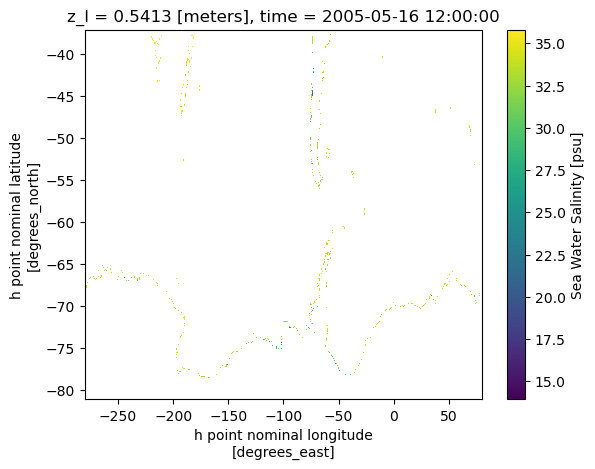

In [20]:
test = var.where(coastal_ocean)
test.plot()

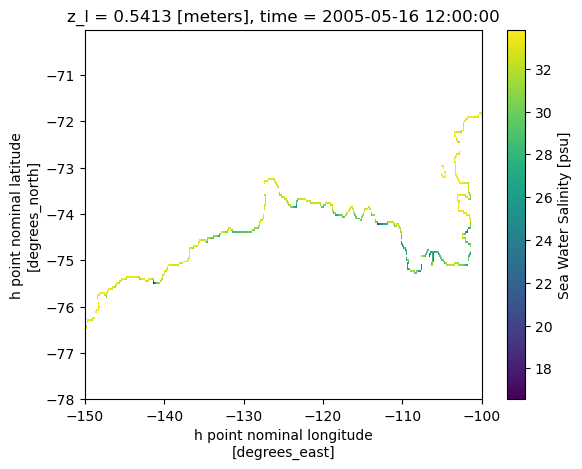

In [22]:
var.where(coastal_ocean).sel(xh=slice(-150,-100),yh=slice(-78,-70)).plot()

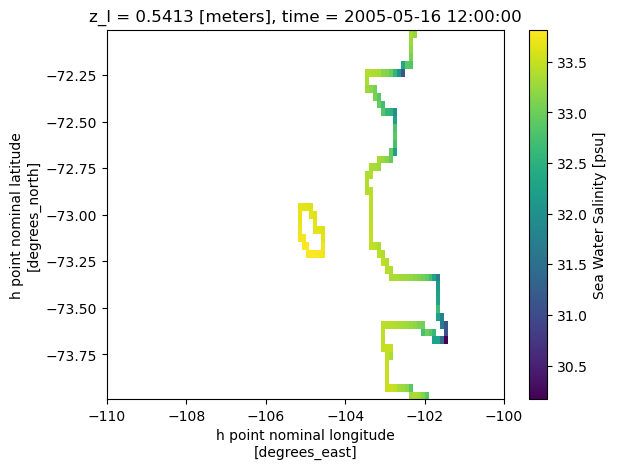

In [23]:
# Post check
var.where(coastal_ocean).sel(xh=slice(-110,-100),yh=slice(-74,-72)).plot()

Looks the same as above. Need to make a decision about whether we want 'steps' on the diagonals or not. 

## Distance transform test

In [24]:
# Land = True
land_bool = np.isnan(depth_1.values)

# Compute distance to nearest land cell
distance = ndi.distance_transform_edt(~land_bool)

# Ocean cells within 1 grid cell of land
coastal_ocean = (distance <= 1) & (~land_bool)

coastal_ocean = xr.DataArray(
    coastal_ocean,
    coords=depth_1.coords,
    dims=depth_1.dims
)

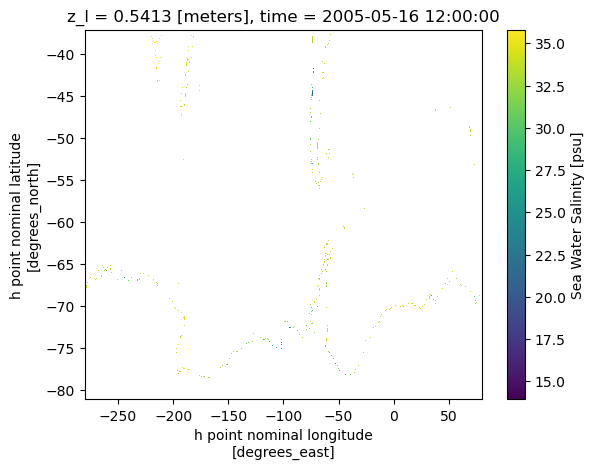

In [29]:
var.where(coastal_ocean).plot()

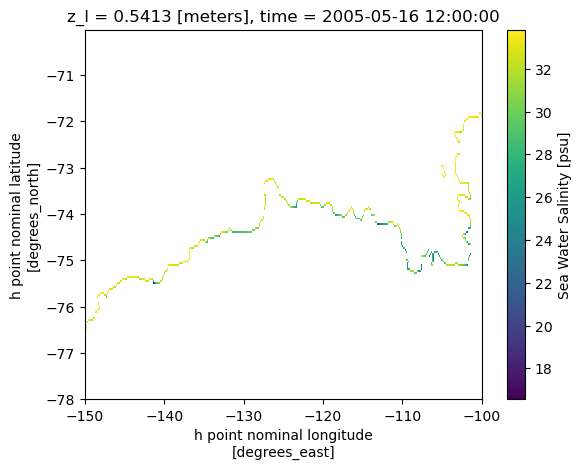

In [25]:
var.where(coastal_ocean).sel(xh=slice(-150,-100),yh=slice(-78,-70)).plot()

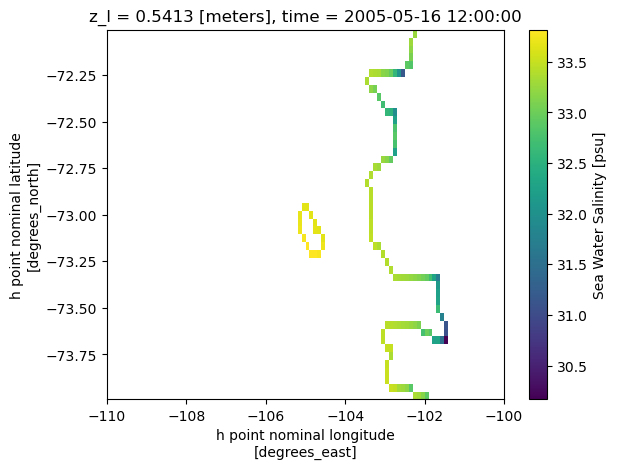

In [27]:
var.where(coastal_ocean).sel(xh=slice(-110,-100),yh=slice(-74,-72)).plot()

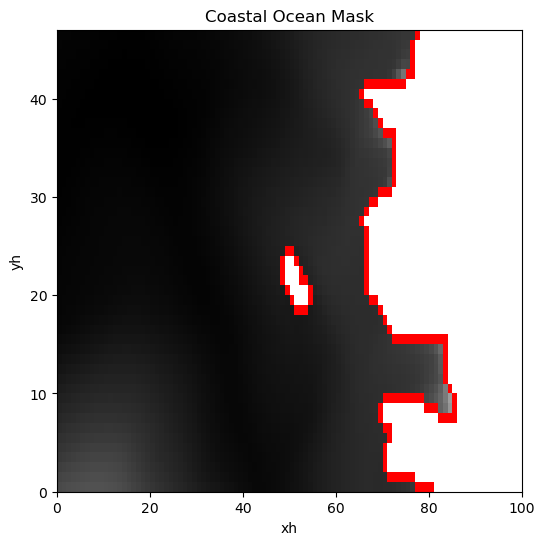

In [28]:
# Sanity check plot
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(6,6))

# Black background
ax.pcolormesh(
    var.sel(xh=slice(-110,-100),
            yh=slice(-74,-72)),
    cmap='binary'
)

# Red overlay
ax.pcolormesh(
    var.where(coastal_ocean).sel(
        xh=slice(-110,-100),
        yh=slice(-74,-72)
    ),
    cmap=ListedColormap(['red'])
)

plt.xlabel('xh')
plt.ylabel('yh')
plt.title("Coastal Ocean Mask")
plt.show()

Looks good to me!